In [1]:
# This primer data validation notebook is intended to retrieve information about the primer dataset.
# Some data in that used in this notebook will used to provide baseline information for the thesis experiment.

#!/usr/bin/env python3

# Adjust the system path to include the parent directory
import sys
sys.path.append('..')

# Syncing the source module with current notebook environment
# This module will automatically running the module syncronization script
import module

print("Data validation notebook")

Data validation notebook


/home/inadio/skripkir/apex-spotter/.venv/lib/python3.10/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/inadio/skripkir/apex-spotter/.venv/lib/python3.10/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


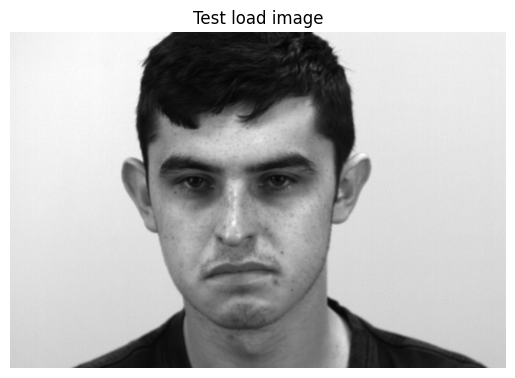

(Text(0.5, 1.0, 'Test load image'),
 (-0.5, 959.5, 649.5, -0.5),
 None)

In [ ]:
# Setup the dataset for apex frame spotting task
import os
import re
import glob
import cv2
import matplotlib.pyplot as plt

DATASET_PATH = '/home/inadio/.undergrade-thesis/datasets/samm-i'

# Validate the dataset path should be exist
# Raise an assertion error if the path does not exist
assert os.path.exists(os.path.expanduser(DATASET_PATH)), "Dataset path does not exist."

# List all data files in the dataset list
files = glob.glob(os.path.join(DATASET_PATH, '**', '*.jpg'), recursive=True)
files.sort(key=lambda p: [int(i) if i.isdigit() else i.lower() for part in os.path.relpath(p, DATASET_PATH).split(os.sep) for i in re.split(r'(\d+)', part) if i])

image = cv2.imread(files[0])
plt.title('Test load image'), plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)), plt.axis('off'), plt.show()

/home/inadio/skripkir/apex-spotter/.venv/lib/python3.10/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/inadio/skripkir/apex-spotter/.venv/lib/python3.10/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


(650, 960, 3) (650, 960, 3)


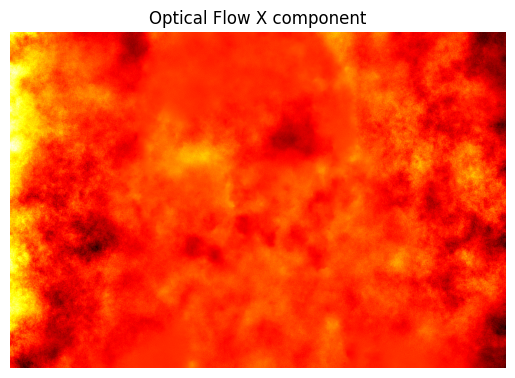

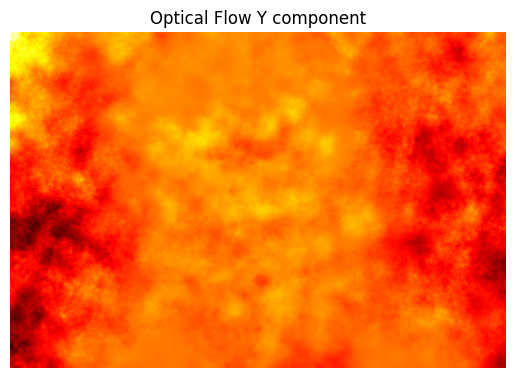

(Text(0.5, 1.0, 'Optical Flow Y component'), (-0.5, 959.5, 649.5, -0.5), None)

In [2]:
# Trying to process two frames from the dataset using GPU

import cv2
import cupy as cp
import matplotlib.pyplot as plt


frame1 = cv2.imread(files[0])
frame2 = cv2.imread(files[1])

# Transfer frames into cupy array for GPU processing
gpu_frame1 = cp.asarray(frame1)
gpu_frame2 = cp.asarray(frame2)

print(gpu_frame1.shape, gpu_frame2.shape)

gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

# Convert into cuda gpu mat
gpu_frame1 = cv2.cuda_GpuMat()
gpu_frame2 = cv2.cuda_GpuMat()
gpu_frame1.upload(gray1)
gpu_frame2.upload(gray2)

tvl1 = cv2.cuda.OpticalFlowDual_TVL1_create()
gpu_flow = tvl1.calc(gpu_frame1, gpu_frame2, None)

flow = gpu_flow.download()

plt.imshow(flow[..., 0], cmap='hot')
plt.title('Optical Flow X component'), plt.axis('off'), plt.show()

plt.imshow(flow[..., 1], cmap='hot')
plt.title('Optical Flow Y component'), plt.axis('off'), plt.show()


Processing 69 pairs...


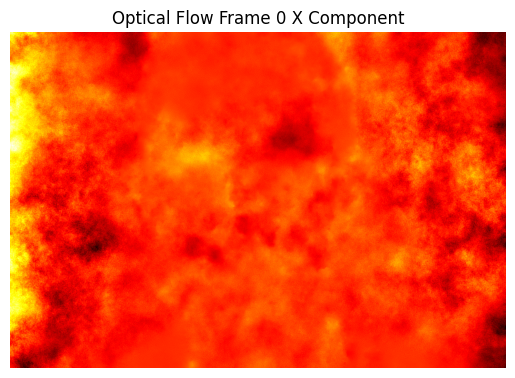

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

tvl1 = cv2.cuda.OpticalFlowDual_TVL1_create()
gpu_prev = cv2.cuda_GpuMat()
gpu_curr = cv2.cuda_GpuMat()
gpu_flow = cv2.cuda_GpuMat()

magnitude_stats = []

selected_frames = files[:70]

print(f"Processing {len(selected_frames)-1} pairs...")

for i in range(len(selected_frames) - 1):
    frame1 = cv2.imread(selected_frames[i], cv2.IMREAD_GRAYSCALE)
    frame2 = cv2.imread(selected_frames[i + 1], cv2.IMREAD_GRAYSCALE)

    gpu_prev.upload(frame1)
    gpu_curr.upload(frame2)

    gpu_flow = tvl1.calc(gpu_prev, gpu_curr, gpu_flow)

    flow = gpu_flow.download()

    u = flow[..., 0]
    v = flow[..., 1]
    mag = np.sqrt(u**2 + v**2)
    mean_val = np.mean(mag)
    
    magnitude_stats.append(mean_val)
    
    if i == 0:
        plt.imshow(flow[..., 0], cmap='hot')
        plt.title(f'Optical Flow Frame {i} X Component')
        plt.axis('off')
        plt.show()

    del frame1, frame2, flow, mag, u, v


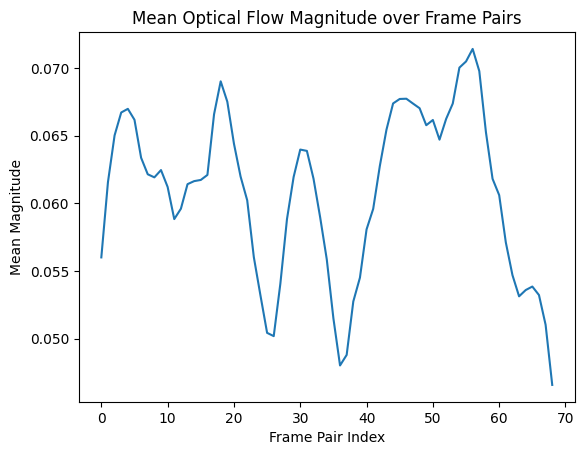

In [5]:
# Display the flow as graph
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter


filtered_stats = savgol_filter(magnitude_stats, 11, 3)

plt.plot(filtered_stats)
plt.title('Mean Optical Flow Magnitude over Frame Pairs')
plt.xlabel('Frame Pair Index')
plt.ylabel('Mean Magnitude')
plt.show()

In [9]:
# Create utility to proceed magnitude stats from video file
import cv2
import numpy as np
from src.features.apex import TVL1

tvl1 = TVL1()

def process_video_optical_flow(video_path):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise RuntimeError(f"Failed to open video file: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Total frames in video: {total_frames}")

    magnitude_stats = []

    ret, prev_frame = cap.read()
    if not ret:
        raise RuntimeError("Failed to read first frame.")

    for frame_idx in range(1, total_frames):
        ret, current_frame = cap.read()

        if not ret:
            raise RuntimeError(f"Failed to read frame at index {frame_idx}.")

        mag = tvl1.compute(prev_frame, current_frame).magnitude()
        mean_val = np.mean(mag)

        magnitude_stats.append(mean_val)

        prev_frame = current_frame

    cap.release()
    return magnitude_stats

Total frames in video: 2689
Processed 2688 frame pairs from 2689 frames


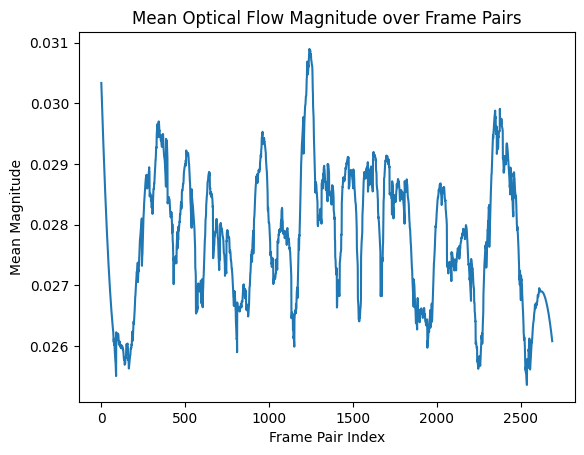

In [23]:
from scipy.signal import savgol_filter


VIDEO_PATH = '/home/inadio/.undergrade-thesis/datasets/primary/videos/20250520125029.avi'

magnitude_stats = process_video_optical_flow(VIDEO_PATH) 
smooted_stats   = savgol_filter(magnitude_stats, window_length=144, polyorder=2)

plt.plot(smooted_stats)
plt.title('Mean Optical Flow Magnitude over Frame Pairs')
plt.xlabel('Frame Pair Index')
plt.ylabel('Mean Magnitude')
plt.show()

Total frames in video: 2697


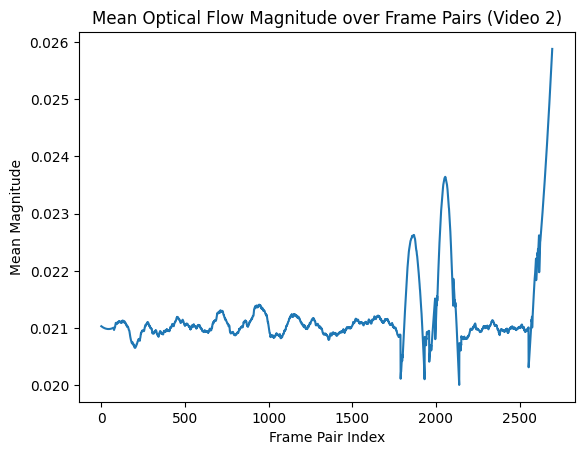

In [11]:
from scipy.signal import savgol_filter


VIDEO_PATH2 = '/home/inadio/.undergrade-thesis/datasets/primary/videos/20250520132508.avi'

magnitude_stats2 = process_video_optical_flow(VIDEO_PATH2)
smooted_stats2   = savgol_filter(magnitude_stats2, window_length=144, polyorder=2)

plt.plot(smooted_stats2)
plt.title('Mean Optical Flow Magnitude over Frame Pairs (Video 2)')
plt.xlabel('Frame Pair Index')
plt.ylabel('Mean Magnitude')
plt.show()

In [37]:
# Extract information detail from optical flow results

import numpy as np


def extract_stats(mag):
    arr = np.array(mag)
    
    return {
        'std': np.std(arr),
        'variance': np.var(arr),
        'coef_variation': np.std(arr) / np.mean(arr) if np.mean(arr) != 0 else 0,
        'range': np.max(arr) - np.min(arr),
        'iqr': np.percentile(arr, 75) - np.percentile(arr, 25),
        'zero_crossings': np.sum(np.diff(np.sign(arr)) != 0),
        'mean_abs_diff': np.mean(np.abs(np.diff(arr))),
        'num_peaks': len(np.where(np.diff(np.sign(np.diff(arr))) < 0)[0]),
        'high_freq_energy': np.sum(np.fft.fft(arr)**2) / len(arr),
    }


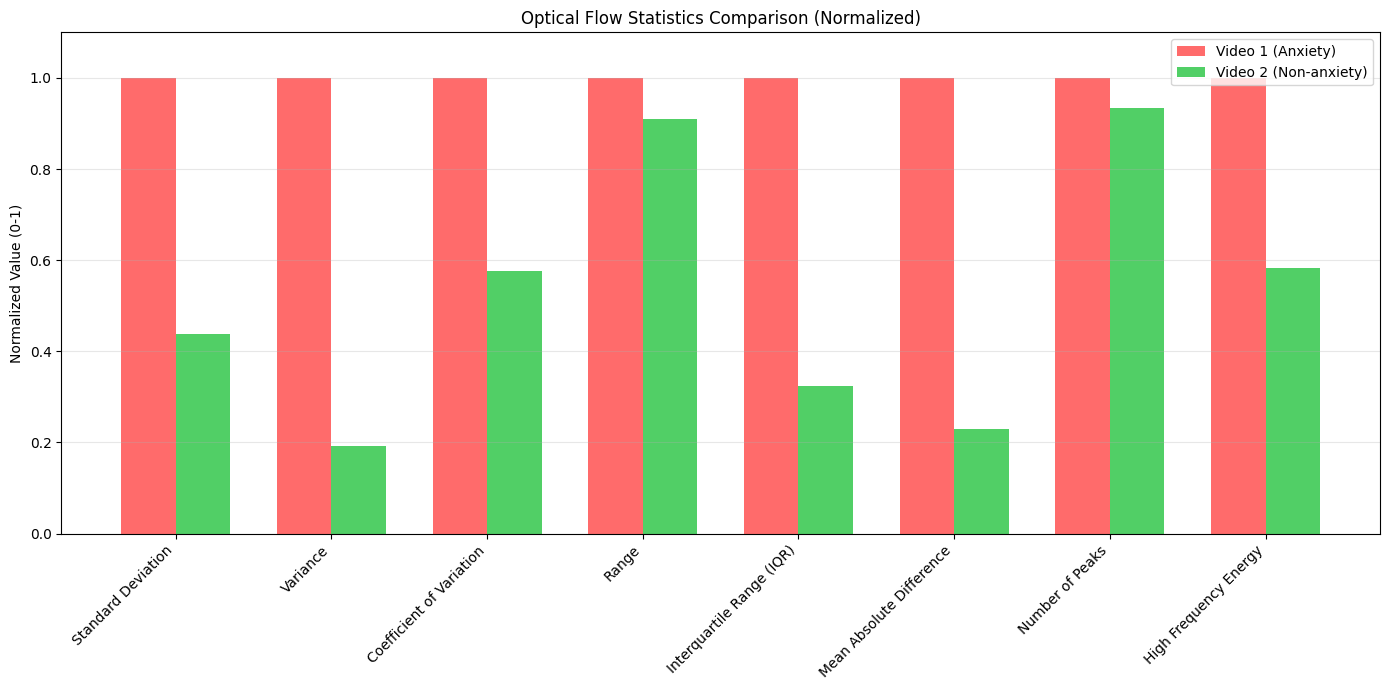

Standard Deviation: Video 1 = 0.007381839018756707, Video 2 = 0.0032384374275635547
Variance: Video 1 = 5.449154729883899e-05, Video 2 = 1.0487476972244453e-05
Coefficient of Variation: Video 1 = 0.26530219315651615, Video 2 = 0.15263349659742698
Range: Video 1 = 0.08535732887685299, Video 2 = 0.07766735181212425
Interquartile Range (IQR): Video 1 = 0.0026894542388617992, Video 2 = 0.0008700089529156685
Mean Absolute Difference: Video 1 = 0.004489656033810293, Video 2 = 0.001030400348395275
Number of Peaks: Video 1 = 881, Video 2 = 822
High Frequency Energy: Video 1 = 2.079157152902299, Video 2 = 1.213249380432162


In [35]:
import matplotlib.pyplot as plt
import numpy as np


stats1 = extract_stats(magnitude_stats)
stats2 = extract_stats(magnitude_stats2)

metrics = {
    'Standard Deviation': (stats1['std'], stats2['std']),
    'Variance': (stats1['variance'], stats2['variance']),
    'Coefficient of Variation': (stats1['coef_variation'], stats2['coef_variation']),
    'Range': (stats1['range'], stats2['range']),
    'Interquartile Range (IQR)': (stats1['iqr'], stats2['iqr']),
    'Mean Absolute Difference': (stats1['mean_abs_diff'], stats2['mean_abs_diff']),
    'Number of Peaks': (stats1['num_peaks'], stats2['num_peaks']),
    'High Frequency Energy': (abs(stats1['high_freq_energy']), abs(stats2['high_freq_energy'])),
}

normalized_metrics = {}
for name, (v1, v2) in metrics.items():
    max_val = max(v1, v2)
    if max_val > 0:
        normalized_metrics[name] = (v1/max_val, v2/max_val)
    else:
        normalized_metrics[name] = (0, 0)

x = list(normalized_metrics.keys())
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.bar(np.arange(len(x)) - width/2, [v[0] for v in normalized_metrics.values()], 
               width, label='Video 1 (Anxiety)', color='#ff6b6b')
bars2 = ax.bar(np.arange(len(x)) + width/2, [v[1] for v in normalized_metrics.values()], 
               width, label='Video 2 (Non-anxiety)', color='#51cf66')

ax.set_xticks(np.arange(len(x)))
ax.set_xticklabels(x, rotation=45, ha='right')
ax.set_ylabel('Normalized Value (0-1)')
ax.set_title('Optical Flow Statistics Comparison (Normalized)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()


for name, (v1, v2) in metrics.items():
    print(f"{name}: Video 1 = {v1}, Video 2 = {v2}")